# Simulation Based Inference to Remove Sampling Bias - both variants

In [ ]:
import os
import pickle
from itertools import product
from time import perf_counter
from functools import partial

import bayesflow as bf
import numpy as np
import pandas as pd
import tensorflow as tf
from bayesflow import default_settings as defaults
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.helper_networks import MultiConv1D
from bayesflow.networks import InvertibleNetwork
from bayesflow.simulation import GenerativeModel, Prior, Simulator, ContextGenerator
from bayesflow.trainers import Trainer
from matplotlib import pyplot as plt
from tarp import get_tarp_coverage
from tensorflow.keras.layers import Dense, LSTM, GRU, Bidirectional
from tensorflow.keras.models import Sequential
from tqdm import tqdm

from helper_functions import measure_bias, normalize_household_data

In [ ]:
job_array_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0))
print(f"Job array ID: {job_array_id}")
n_procs = int(os.environ.get('SLURM_CPUS_PER_TASK', 1))

In [ ]:
train_network = False
presimulate = False
batch_size = 128
iterations_per_epoch = 1000
# 10000 batches to be generated, 10 epoch until batches are used up
max_epochs = 250  # 100

## Define model and prior

In [ ]:
# define the prior    
def prior(batch_size: int) -> np.ndarray:
    param_batch = np.zeros((batch_size, 8))
    # beta
    param_batch[:, 0] = np.random.normal(0, 1, batch_size)
    # mu
    param_batch[:, 1:] = np.random.normal(0, 1, (batch_size, 7))
    return param_batch

# for normalization of the parameters
prior_mean = np.array([0., 0, 0, 0, 0, 0, 0, 0])
prior_std = np.array([1., 1, 1, 1, 1, 1, 1, 1])

param_names = ['beta',
               'mu_inf_SC', 'mu_inf_SA', 'mu_inf_AI', 'mu_inf_AC', 'mu_inf_AA',
               'mu_susc_C', 'mu_susc_A']
    
assert prior_mean.size == prior_std.size, 'Number of parameters do not match'
assert prior_mean.size == prior(1).shape[1], \
    'Number of parameters do not match in prior'

In [ ]:
# check if GPU is available
n_gpus = len(tf.config.experimental.list_physical_devices('GPU'))
print("Num GPUs Available: ", n_gpus)

if n_gpus > 0:
    def simulator(params: np.ndarray,
                  selection_procedure: str,
                  variant: str,
                  minimal_length: int,
                  fix_parameters: bool = True)  -> np.ndarray:
        # gpu cannot handle R modules for some reason
        raise NotImplementedError('simulator function not implemented')
else:
    from Simulator.simulator import simulator

n_params = len(param_names)

# if name starts with mu, create log name
log_param_names = []
for p_name in param_names:
    log_param_names.append(f'log({p_name})')

In [ ]:
assert n_params == prior(1).shape[1], 'Number of parameters in prior do not match names'
assert n_params == prior_mean.size, 'Number of parameters in normalization do not match names'
print(f"Number of parameters: {n_params}")

In [ ]:
# plot prior
fix, ax = plt.subplots(1, len(param_names), figsize=(10, 4), sharey=True, tight_layout=True)
n_samples = 1000
prior_samples = prior(n_samples)
for i in range(len(param_names)):
    ax[i].hist(prior_samples[:, i], bins=20, density=True)
    ax[i].set_xlabel(log_param_names[i])
plt.show()

## Define the generative model for BayesFlow

In [ ]:
bayesflow_prior = Prior(
    batch_prior_fun=prior,
    param_names=log_param_names
)
gen = ContextGenerator(
    batchable_context_fun=lambda : np.random.choice(['pedcov', 'random']),
    non_batchable_context_fun=lambda : np.random.choice(['alpha', 'omicron'])
)
bayes_simulator = Simulator(
    simulator_fun=simulator,
    context_generator=gen
)
generative_model = GenerativeModel(
    prior=bayesflow_prior, 
    simulator=bayes_simulator,
    skip_test=True
)

## Generate training data

In [ ]:
presim_folder = 'presimulations_both_variants'

if presimulate:    
    np.random.seed(42)
    print('presimulating')
    start_time = perf_counter()
    from time import sleep
    sleep(job_array_id)

    for job_1000 in range(10):
        add_to_id = job_1000 * 1000
        # we create on batch per job and save it in a folder
        epoch_id = (job_array_id+add_to_id) // iterations_per_epoch
        print(f'presimulating epoch {epoch_id} job {job_array_id+add_to_id}')
        os.makedirs(presim_folder, exist_ok=True)
        generative_model.presimulate_and_save(batch_size=4, #batch_size, 
                                              folder_path=f'{presim_folder}/epoch_{epoch_id}',
                                              iterations_per_epoch=1,
                                              epochs=1,
                                              extend_from=job_array_id+add_to_id,
                                              disable_user_input=True)
    end_time = perf_counter()
    print(f'simulation time: {(end_time-start_time)/60} minutes')
    #exit()

In [ ]:
# generate validation data
valid_file_name = "valid_data_both_variants"

np.random.seed(42)
n_valid = 256
prior_draws = bayesflow_prior(n_valid // 4)
valid_data_dict = {}

for variant, selection in product(['alpha', 'omicron'], ['pedcov', 'random']):
    
    valid_file_name_vs = f"{valid_file_name}_{variant}_{selection}"
    if os.path.exists(f'sim_data/{valid_file_name_vs}.pickle'):
        with open(f'sim_data/{valid_file_name_vs}.pickle', 'rb') as f:
            valid_data_dict[f'{variant}_{selection}'] = pickle.load(f)
    else:
        print(f"Simulating validation data for {variant} with {selection}")
        new_valid_data = {
            'prior_draws': prior_draws['prior_draws'].copy(),
            'sim_batchable_context': np.array([[selection] for _ in range(n_valid // 4)]),
            'sim_non_batchable_context': np.array([[variant] for _ in range(n_valid // 4)]),
        }
        new_valid_data['sim_data'] = np.array([simulator(params,
                                                         selection_procedure=selection,
                                                         variant=variant)
                                               for params in new_valid_data['prior_draws']])
        # save the data
        with open(f'sim_data/{valid_file_name_vs}.pickle', 'wb') as f:
            pickle.dump(new_valid_data, f)
        valid_data_dict[f'{variant}_{selection}'] = new_valid_data
        
# we cannot use both variants at the same time for validation since not batchable
valid_data_alpha = {key: np.concatenate((valid_data_dict['alpha_pedcov'][key],
                                   valid_data_dict['alpha_random'][key])
                                  ) for key in valid_data_dict['alpha_pedcov'].keys()}
valid_data_omicron = {key: np.concatenate((valid_data_dict['omicron_pedcov'][key],
                                   valid_data_dict['omicron_random'][key])
                                  ) for key in valid_data_dict['omicron_pedcov'].keys()}

In [ ]:
def configurator(forward_dict: dict, drop_random: bool = False) -> dict:
    out_dict = {}

    # Extract data (already normalized)
    x = forward_dict["sim_data"]
    out_dict['summary_conditions'] = x.astype(np.float32)
    
    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        # normalize
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params.astype(np.float32)
    
    if not drop_random:
        # Extract context
        variant_selection = np.array(
            [[0. if v == 'alpha' else 1., 0. if s == 'pedcov' else 1.] 
             for v, s in zip(forward_dict['sim_non_batchable_context'], forward_dict['sim_batchable_context'])]
        )
    else:
        # Extract context
        variant_selection = np.array(
            [[0. if v == 'alpha' else 1.] 
             for v in forward_dict['sim_non_batchable_context']]
        )
        keep_indices = np.where(forward_dict['sim_batchable_context'] == 'pedcov')[0]
        variant_selection = variant_selection[keep_indices]
        
        out_dict['summary_conditions'] = out_dict['summary_conditions'][keep_indices]
        if 'parameters' in out_dict.keys():
            out_dict['parameters'] = out_dict['parameters'][keep_indices]
        
    out_dict['direct_condition'] = variant_selection.astype(np.float32)
    return out_dict

In [ ]:
def renormalize_params(params: np.ndarray, log_transform: bool = False) -> np.ndarray:
    un_scaled_params = params.copy()
    un_scaled_params = un_scaled_params * prior_std + prior_mean
    
    if log_transform:
        # params might be a batch of samples or single set of parameters
        for p_i in range(n_params):
            if un_scaled_params.ndim == 2:
                un_scaled_params[:, p_i] = np.exp(un_scaled_params[:, p_i])
            elif un_scaled_params.ndim == 3:
                 un_scaled_params[:, :, p_i] = np.exp(un_scaled_params[:, :, p_i])
            else:
                raise ValueError('Invalid number of dimensions')
    return un_scaled_params

## Define the neural network architectures

In [ ]:
# define the network    
class GroupSummaryNetwork(tf.keras.Model):
    """Network to summarize the data of groups of cells.  Each group is passed through a series of convolutional layers
    followed by an LSTM layer. The output of the LSTM layer is then pooled across the groups and dense layer applied
    to obtain a summary of fixed dimensionality. The network is invariant to the order of the groups.
    """
    def __init__(
            self,
            summary_dim,
            num_conv_layers=2,
            rnn_units=128,
            bidirectional=True,
            conv_settings=None,
            use_attention=False,
            use_GRU=True,
            **kwargs
    ):
        super().__init__(**kwargs)

        if conv_settings is None:
            conv_settings = defaults.DEFAULT_SETTING_MULTI_CONV

        conv = Sequential([MultiConv1D(conv_settings) for _ in range(num_conv_layers)])
        self.group_conv = tf.keras.layers.TimeDistributed(conv)
        self.use_attention = use_attention
        self.pooling = tf.keras.layers.GlobalAveragePooling1D()
        
        if self.use_attention:
            self.attention = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=rnn_units)
        
        if use_GRU:
            rnn = Bidirectional(GRU(rnn_units, return_sequences=use_attention)) if bidirectional else GRU(rnn_units, return_sequences=use_attention)
        else:
            rnn = Bidirectional(LSTM(rnn_units, return_sequences=use_attention)) if bidirectional else LSTM(rnn_units, return_sequences=use_attention)   
        self.group_rnn = tf.keras.layers.TimeDistributed(rnn)
            
        self.out_layer = Dense(summary_dim, activation="linear")
        self.summary_dim = summary_dim

    def call(self, x, **kwargs):
        """Performs a forward pass through the network by first passing `x` through the same rnn network for
        each household and then pooling the outputs across households.

        Parameters
        ----------
        x : tf.Tensor
            Input of shape (batch_size, n_groups, n_time_steps, n_features)

        Returns
        -------
        out : tf.Tensor
            Output of shape (batch_size, summary_dim)
        """
        # Apply the RNN to each group
        out = self.group_conv(x, **kwargs) 
        out = self.group_rnn(out, **kwargs)  # (batch_size, n_groups, lstm_units)
        # if attention is used, return full sequence (batch_size, n_groups, n_time_steps, lstm_units)
        # bidirectional LSTM returns 2*lstm_units

        if self.use_attention:
            # learn a query vector to attend over the time points
            query = tf.reduce_mean(out, axis=1)
            # Reshape query to match the required shape for attention
            query = tf.expand_dims(query, axis=1)  # (batch_size, 1, n_time_steps, lstm_units)
            out = self.attention(query, out, **kwargs)  # (batch_size, 1, n_time_steps, lstm_units)
            out = tf.squeeze(out, axis=1)  # Remove the extra dimension (batch_size, n_time_steps, lstm_units)
            out = self.pooling(out, **kwargs)  # (batch_size, 1, lstm_units)
        else:
            # pooling over groups, this totally invariants to the order of the groups
            out = self.pooling(out, **kwargs)  # (batch_size, lstm_units)
        # apply dense layer
        out = self.out_layer(out, **kwargs)  # (batch_size, summary_dim)
        return out

In [ ]:
# settings
net_id = 3 #3

coupling_settings_spline = {
    "num_dense": 3,
    "dense_args": dict(
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    "dropout_prob": 0.2,
    "bins": 16,
}
summary_loss = 'MMD'
drop_random_selection = False

if net_id == 0:
    amortizer_name = 'amortizer-sampling-bias-both_variants-6'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 6
    use_attention = False
elif net_id == 1:
    amortizer_name = 'amortizer-sampling-bias-both_variants-6-attention'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 6
    use_attention = True
elif net_id == 2:
    amortizer_name = 'amortizer-sampling-bias-both_variants-7'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 7
    use_attention = False
elif net_id == 3:
    amortizer_name = 'amortizer-sampling-bias-both_variants-7-attention'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 7
    use_attention = True
elif net_id == 4:
    amortizer_name = 'amortizer-sampling-bias-both_variants-8'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 8
    use_attention = False
elif net_id == 5:
    amortizer_name = 'amortizer-sampling-bias-both_variants-8-attention'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 8
    use_attention = True
elif net_id == 6:
    amortizer_name = 'amortizer-sampling-bias-both_variants-6-attention-pedcov'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 7
    use_attention = True
    drop_random_selection = True
elif net_id == 7:
    amortizer_name = 'amortizer-sampling-bias-both_variants-7-attention-pedcov'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 8
    use_attention = True
    drop_random_selection = True
elif net_id == 8:
    amortizer_name = 'amortizer-sampling-bias-both_variants-8-attention-pedcov'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 8
    use_attention = True
    drop_random_selection = True
else:
    raise ValueError('Invalid network id')

In [ ]:
summary_net = GroupSummaryNetwork(
    summary_dim=n_params*2,
    rnn_units=32,  # multiple of 32 hidden units
    use_attention=use_attention,
)

inference_net = InvertibleNetwork(
    num_params=n_params,
    num_coupling_layers=num_coupling_layers,
    coupling_design='spline',
    coupling_settings=coupling_settings,
    permutation="learnable"
)

In [ ]:
amortizer = AmortizedPosterior(
    inference_net=inference_net, 
    summary_net=summary_net,
    summary_loss_fun=summary_loss
)
os.makedirs("amortizer", exist_ok=True)
checkpoint_path = 'amortizer/' + amortizer_name
print(checkpoint_path)

# build the trainer with networks and generative model
max_to_keep = 7
trainer = Trainer(
    amortizer=amortizer,
    configurator=partial(configurator, drop_random=drop_random_selection),
    generative_model=generative_model,
    checkpoint_path=checkpoint_path,
    skip_checks=True,
    max_to_keep=max_to_keep
)

In [ ]:
def custom_loader(file_path):
    """Uses pickle to load, but each path is folder with multiple files, each one batch"""
    # load all files in folder
    loaded_presimulations = []
    for file in os.listdir(file_path):
        with open(os.path.join(file_path, file), 'rb') as batch_file:
            batch = pickle.load(batch_file)[0]
            assert isinstance(batch, dict)  # only one batch per file
            loaded_presimulations.append(batch)
    # shuffle list, so iterations are random, only batches stay the same
    np.random.shuffle(loaded_presimulations)
    return loaded_presimulations

## Train the network

In [ ]:
if train_network:
    # simulation done before, start training now
    trainer._setup_optimizer(
        optimizer=None,
        epochs=max_epochs,
        iterations_per_epoch=iterations_per_epoch
    )
    optimizer = trainer.optimizer

    start_time = perf_counter()
    history = trainer.train_from_presimulation(
        presimulation_path=presim_folder,
        optimizer=optimizer,
        max_epochs=max_epochs,
        early_stopping=True,
        custom_loader=custom_loader,
        validation_sims=valid_data_alpha
    )

    end_time = perf_counter()
    print(f'training time: {(end_time-start_time)/60} minutes')
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

In [ ]:
# Check if training converged
if np.isnan(history['val_losses'].iloc[-1]).any():
    print('Training failed with NaN loss at the end')
    if np.isnan(history['val_losses'].iloc[-max_to_keep:]).all():
        print('Training failed with NaN loss for all latest checkpoints')

# Find the checkpoint with the lowest validation loss out of the last 7
recent_losses = history['val_losses'].iloc[-max_to_keep:]
best_valid_epoch = recent_losses['Loss'].idxmin() + 1  # checkpoints are 1-based indexed
new_checkpoint = trainer.manager.latest_checkpoint.rsplit('-', 1)[0] + f'-{best_valid_epoch}'    
trainer.checkpoint.restore(new_checkpoint)
print("Networks loaded from {}".format(new_checkpoint))
print(f"Best validation loss: {recent_losses['Loss'].min()}")

## Check the training convergence

In [ ]:
results_folder = 'results_both_variants'
os.makedirs(results_folder, exist_ok=True)

In [ ]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [ ]:
test_sims_alpha = trainer.configurator(valid_data_alpha)
test_sims_omicron = trainer.configurator(valid_data_omicron)

In [ ]:
# we need to join samples from both variants to check SBC and other diagnostics
posterior_samples_alpha = amortizer.sample(test_sims_alpha, n_samples=100)
posterior_samples_omicron = amortizer.sample(test_sims_omicron, n_samples=100)
posterior_samples = np.concatenate((posterior_samples_alpha, posterior_samples_omicron), axis=0)
posterior_samples = renormalize_params(posterior_samples)

prior_draws_alpha = renormalize_params(test_sims_alpha["parameters"])
prior_draws_omicron = renormalize_params(test_sims_omicron["parameters"])
prior_draws = np.concatenate((prior_draws_alpha, prior_draws_omicron), axis=0)

In [ ]:
fig = bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=log_param_names)
fig.savefig(f'{results_folder}/{amortizer_name}_sbc.png')

In [ ]:
# remove nan
remove = np.any(np.isnan(posterior_samples), axis=(1, 2))
if np.any(remove):
    print(f"Removing {np.sum(remove)} entries with nan")

In [ ]:
bf.diagnostics.plot_recovery(posterior_samples[~remove], prior_draws[~remove], param_names=log_param_names);

In [ ]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=log_param_names);

In [ ]:
posterior_samples_reshaped = posterior_samples.reshape(posterior_samples.shape[1], posterior_samples.shape[0], posterior_samples.shape[2])
ecp_bootstrap, alpha = get_tarp_coverage(posterior_samples_reshaped, prior_draws, references='random', #posterior_samples_reshaped[0, :, :]
                                         metric='euclidean', norm=True, bootstrap=True)

In [ ]:
k_sigma = [1, 2, 3]

_, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label="Ideal case")
ax.plot(alpha, ecp_bootstrap.mean(axis=0), label='TARP')
for k in k_sigma:
    ax.fill_between(alpha, 
                    ecp_bootstrap.mean(axis=0) - k * ecp_bootstrap.std(axis=0), 
                    ecp_bootstrap.mean(axis=0) + k * ecp_bootstrap.std(axis=0), 
                    alpha = 0.7)
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")
plt.show()

# Test inference on synthetic data for both recruitment scenarios and variants

In [ ]:
n_samples = 100

test_scenarios_posterior_samples = {}
for test_scenario in valid_data_dict.keys():
    print(f"Testing scenario {test_scenario}")
    test_sims = trainer.configurator(valid_data_dict[test_scenario])
    posterior_samples = amortizer.sample(test_sims, n_samples=n_samples)
    posterior_samples = renormalize_params(posterior_samples)
    test_scenarios_posterior_samples[test_scenario] = posterior_samples
    prior_draws = renormalize_params(test_sims["parameters"])
    fig = bf.diagnostics.plot_recovery(posterior_samples, prior_draws,
                                       ylabel=f'Estimated\n{test_scenario}',
                                       param_names=log_param_names)
    fig.savefig(f'{results_folder}/{amortizer_name}_recovery_{test_scenario}.png')

### Check summary statistics in latent space

One should not be able to distinguish between the two variants or the scenarios in the latent space.
This is a good sign that the amortizer is working correctly.
Later we can test if the real data is also indistinguishable in the latent space.


In [ ]:
if summary_loss is not None:
    np.random.seed(0)
    sim_id = np.random.randint(0, n_valid // 4)
    for variant, selection in product(['alpha', 'omicron'], ['pedcov', 'random']):
        test_sims = trainer.configurator(valid_data_dict['alpha_pedcov'])
        test_sims_rand = trainer.configurator(valid_data_dict[f'{variant}_{selection}'])

        MMD_sampling_distribution, MMD_observed = trainer.mmd_hypothesis_test(
            observed_data=test_sims_rand["summary_conditions"][sim_id][np.newaxis],
            reference_data=test_sims,  # if not provided, will use the generative model
            bootstrap=True  # if True, use the reference data as null samples
        )
        fig = bf.diagnostics.plot_mmd_hypothesis_test(MMD_sampling_distribution, MMD_observed)
        plt.title(f"MMD Hypothesis Test ({variant}, {selection})")
        #fig.savefig(f'{results_folder}/{amortizer_name} MMD.png', bbox_inches='tight')
        plt.show()

## Bias Estimation

bias found in simulation study (when using PedCov as selection procedure) with MCMC:
- overestimation of mu_inf_SA, mu_inf_AA (infectiousness of adults)
- underestimation of mu_susc_A (susceptibility of adults)

Here we should not see any bias anymore, since we condition on the recruitment procedure and variant.

In [ ]:
prior_draws_test = valid_data_dict['alpha_pedcov']['prior_draws']  # is the same for all scenarios

for variant in ['alpha', 'omicron']:
    print('Variant:', variant)
    # regress median of PedCov recruitment on Random recruitment
    #slopes = []
    #intercepts = []
    #for i in range(n_params):
    #    median_pedcov = np.median(test_scenarios_posterior_samples[f'{variant}_pedcov'], axis=1)[:, i]
    #    median_rand = np.median(test_scenarios_posterior_samples[f'{variant}_random'], axis=1)[:, i]
    #    slope, intercept, r_value, p_value, std_err = linregress(median_pedcov, median_rand)
    #    slopes.append(slope)
     #   intercepts.append(intercept)
        
    fig = bf.diagnostics.plot_recovery(test_scenarios_posterior_samples[f'{variant}_random'], 
                                       np.median(test_scenarios_posterior_samples[f'{variant}_pedcov'], axis=1), 
                                       xlabel='Median PedCov Recruitment',
                                       ylabel=f'Random Recruitment \n {variant}',
                                       param_names=log_param_names)
    # get axis
    #ax = fig.get_axes()
    #for i, a in enumerate(ax):
    #    x = np.linspace(*a.get_xlim())
    #    a.plot(x, slopes[i] * x + intercepts[i], color='black')
    #fig.savefig(f'{results_folder}/{amortizer_name}_recovery_{variant}_pedcov_vs_rand.png')
    
    bias_per_parameter = measure_bias(
        prior_draws_test,  
        np.median(test_scenarios_posterior_samples[f'{variant}_pedcov'], axis=1),
        param_names
    )
    bias_per_parameter_rand = measure_bias(
        prior_draws_test, 
        np.median(test_scenarios_posterior_samples[f'{variant}_random'], axis=1),
        param_names
    )
    
    print("Bias metrics per parameter - PedCov")
    print(bias_per_parameter.to_string(index=False))
    
    print("\nBias metrics per parameter - Random")
    print(bias_per_parameter_rand.to_string(index=False))

### Simulation Study

All parameters are set to 1 besides one parameter. Inference workflow applied on the full model still. Check if for the changing parameter the true parameter is still recovered.

Here we tell the network the wrong selection procedure. Results should be biased.

In [ ]:
# generate simulation study
simulation_study_file_name = "sim_study_data_both_variants"
n_sims_per_param = 50

np.random.seed(42)
prior_draws_sim_study = bayesflow_prior(n_sims_per_param)['prior_draws']
prior_draws_sim_study[:, 0] = np.log(0.2)  # fix beta
sim_study_dict = {}
sim_study_bias_dict = {}

for variant, selection in product(['alpha', 'omicron'], ['pedcov', 'random']):
    
    study_file_name_vs = f"{simulation_study_file_name}_{variant}_{selection}"
    if os.path.exists(f'sim_data/{study_file_name_vs}.pickle'):
        with open(f'sim_data/{study_file_name_vs}.pickle', 'rb') as f:
            sim_study_dict[f'{variant}_{selection}'] = pickle.load(f)
    else:
        print(f"Simulating simulation study for {variant} with {selection}")
        new_sim_data = {
            'prior_draws': np.zeros((n_params-1, n_sims_per_param, n_params)),  # all parameters are set to log(1)
            'sim_batchable_context': np.array([[[selection] for _ in range(n_sims_per_param)]
                                               for _ in range(n_params-1)]),
            'sim_non_batchable_context': np.array([[[variant] for _ in range(n_sims_per_param)]
                                                   for _ in range(n_params-1)]),
            'sim_data': np.empty((n_params-1, n_sims_per_param,
                                  valid_data_dict[f'{variant}_{selection}']['sim_data'].shape[1],
                                  valid_data_dict[f'{variant}_{selection}']['sim_data'].shape[2], 
                              valid_data_dict[f'{variant}_{selection}']['sim_data'].shape[3])),
        }
        for i in range(1, n_params):  # we do not want to do this for beta
            # set all except the i-th parameter to log(1)
            new_sim_data['prior_draws'][i-1, :, i] = prior_draws_sim_study.copy()[:, i]
            new_sim_data['prior_draws'][i-1, :, 0] = np.log(0.2)  # fix beta
            new_sim_data['sim_data'][i-1] = np.array([simulator(params,
                                                                selection_procedure=selection,
                                                                variant=variant) 
                                                      for params in new_sim_data['prior_draws'][i-1]])
        # save the data
        with open(f'sim_data/{study_file_name_vs}.pickle', 'wb') as f:
            pickle.dump(new_sim_data, f)
        sim_study_dict[f'{variant}_{selection}'] = new_sim_data

In [ ]:
# perform inference on simulation study
results_sim_study = {} 
selection_data = ['pedcov', 'random'][1]
selection_inference = ['pedcov', 'random'][1]
n_samples_study = 100

for variant in ['alpha', 'omicron']:
    print(f'Inference on simulation study for: {variant}, data is generated with {selection_data}, '
          f'inference assumes {selection_inference}')
    # estimate median and CI for each parameter
    results_sim_study_vs = {
        'median': np.ones((n_params-1, n_sims_per_param)) * np.nan,
        'CI': np.ones((n_params-1, 6, n_sims_per_param)) * np.nan,
        'overall_median_error': np.ones((n_params-1, n_sims_per_param)) * np.nan,
    }
    for i in tqdm(range(1, n_params)):  # we do not do this for beta
        # get data for this parameter
        sim_study_i = {
            'sim_data': sim_study_dict[f'{variant}_{selection_data}']['sim_data'][i-1],
            'prior_draws': sim_study_dict[f'{variant}_{selection_data}']['prior_draws'][i-1],
            # on purpose a different selection procedure than the data was generated with
            'sim_batchable_context': sim_study_dict[f'{variant}_{selection_inference}']['sim_batchable_context'][i-1],
            'sim_non_batchable_context': sim_study_dict[f'{variant}_{selection_inference}']['sim_non_batchable_context'][i-1]
        }
        simulation_study_data_conf = trainer.configurator(sim_study_i)
        # get posterior samples
        posterior_samples_sim_study = (
            amortizer.sample(simulation_study_data_conf, n_samples=n_samples_study)
        )
        posterior_samples_sim_study = renormalize_params(posterior_samples_sim_study, log_transform=True)

        # if i == 0:
        #     # plot posterior samples
        #     bf.diagnostics.plot_posterior_2d(
        #         posterior_draws=posterior_samples_sim_study[0],
        #         prior=prior,
        #         param_names=log_param_names
        #     )
        #     plt.show()

        # get median and CI for each parameter of posterior samples
        # we only care about the changing parameter, the others are set to 1
        results_sim_study_vs['median'][i-1] = np.median(posterior_samples_sim_study[:, :, i], axis=1)
        results_sim_study_vs['CI'][i-1] = np.quantile(posterior_samples_sim_study[:, :, i],
                                                      [0.005, 0.025, 0.1,
                                                       0.995, 0.975, 0.9],
                                                      axis=1)
        # get overall median error
        results_sim_study_vs['overall_median_error'][i-1] = np.sum(
            (np.median(posterior_samples_sim_study, axis=1) - sim_study_i['prior_draws'])**2, axis=1
        )

    results_sim_study[f'{variant}'] = results_sim_study_vs

In [ ]:
# plot the results
fig, ax = plt.subplots(2, n_params-1, sharex=True, sharey=True, figsize=(10, 6), tight_layout=True)
space = 1. / n_sims_per_param
ci_level = 0.95
ci_interval = {0.99: [0, 3], 0.95: [1, 4], 0.8: [2, 5]}[0.95]

sim_study_bias_dict[f'{selection_data}_{selection_inference}_alpha'] = []
sim_study_bias_dict[f'{selection_data}_{selection_inference}_omicron'] = []
for i in range(len(results_sim_study['alpha']['median'])):  # we do not do this for beta
    diff_alpha = results_sim_study['alpha']['median'][i] - np.exp(prior_draws_sim_study[:, i+1])
    diff_omicron = results_sim_study['omicron']['median'][i] - np.exp(prior_draws_sim_study[:, i+1])
    sim_study_bias_dict[f'{selection_data}_{selection_inference}_alpha'].append(diff_alpha)
    sim_study_bias_dict[f'{selection_data}_{selection_inference}_omicron'].append(diff_omicron)

    handle_alpha = ax[0, i].errorbar(np.arange(n_sims_per_param)*space,
                                       diff_alpha,
                                       yerr=np.abs(results_sim_study['alpha']['CI'][i][ci_interval] - results_sim_study['alpha']['median'][i]),
                                       fmt='o', color='b', alpha=0.5, label='alpha')
    handle_alpha_mean = ax[0, i].errorbar((n_sims_per_param-1)*space*0.5,
                                            np.median(diff_alpha),
                                            yerr=np.std(diff_alpha),
                                            color='black', marker='x', label=r'Median bias ($\pm$ std)')

    handle_omicron = ax[1, i].errorbar(np.arange(n_sims_per_param)*space,
                                         diff_omicron,
                                         yerr=np.abs(results_sim_study['omicron']['CI'][i][ci_interval] - results_sim_study['omicron']['median'][i]),
                                         fmt='o', color='orange', alpha=0.5, label='omicron')
    handle_omicron_mean = ax[1, i].errorbar((n_sims_per_param-1)*space*0.5,
                                              np.median(diff_omicron),
                                              yerr=np.std(diff_omicron),
                                              color='black', marker='x', label=r'Median bias ($\pm$ std)')

    ax[1, i].set_xlabel(param_names[i+1])
    ax[1, i].set_xlim(-space-space, n_sims_per_param*space+space)
    ax[1, i].set_xticks([])
ax[0, 0].set_ylabel(f'Posterior median - true parameter\n({round((ci_level*100))}% CI)')
ax[1, 0].set_ylabel(f'Posterior median - true parameter\n({round((ci_level*100))}% CI)')
ax[0, n_params//2-1].set_title(f'Simulation Study - Data: {selection_data}, Inference: {selection_inference}')
ax[0, 0].set_ylim(-5, 10)
fig.legend(handles=[handle_alpha, handle_omicron, handle_alpha_mean],
            loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
fig.savefig(f'{results_folder}/{amortizer_name}_sim_study_data_'
            f'{selection_data}_vs_inference_{selection_inference}.png')
plt.show()

In [ ]:
# plot bias in both scenarios
fig, ax = plt.subplots(2, n_params-1, sharex=True, sharey=True, figsize=(10, 6), tight_layout=True)
for i in range(n_params-1):
    # sample_prior = prior_draws_sim_study[:, i+1] - prior(50)[:, i+1]
    # lower_quantile, upper_quantile = np.quantile(sample_prior, [0.025, 0.975])
    # yerr = np.array([[np.median(sample_prior) - lower_quantile],
    #                             [upper_quantile - np.median(sample_prior)]])
    # for j in [0, 1]:
    #     ax[j, i].errorbar(0.5,
    #                       np.median(sample_prior),
    #                       yerr=yerr,
    #                       color='r', alpha=0.1, marker='x', label=r'Prior')
    # plot a line around 0
    ax[0, i].axhline(0, color='black', ls='--')
    ax[1, i].axhline(0, color='black', ls='--')

    if f'{selection_data}_pedcov_alpha' in sim_study_bias_dict.keys():
        rel_diff_alpha = sim_study_bias_dict[f'{selection_data}_pedcov_alpha'][i] / np.exp(prior_draws_sim_study[:, i+1])
        rel_diff_omicron = sim_study_bias_dict[f'{selection_data}_pedcov_omicron'][i] / np.exp(prior_draws_sim_study[:, i+1])

        # Define the error as [lower_error, upper_error]
        lower_quantile, upper_quantile = np.quantile(rel_diff_alpha, [0.025, 0.975])
        yerr_alpha = np.array([[np.median(rel_diff_alpha) - lower_quantile],
                             [upper_quantile - np.median(rel_diff_alpha)]])
        lower_quantile, upper_quantile = np.quantile(rel_diff_omicron, [0.025, 0.975])
        yerr_omicron = np.array([[np.median(rel_diff_omicron) - lower_quantile],
                                [upper_quantile - np.median(rel_diff_omicron)]])


        handle_alpha_mean = ax[0, i].errorbar(0,
                                               np.median(rel_diff_alpha),
                                               yerr=yerr_alpha,
                                               color='black', marker='x', label=r'Median bias')
        handle_omicron_mean = ax[1, i].errorbar(0,
                                               np.median(rel_diff_omicron),
                                               yerr=yerr_omicron,
                                               color='black', marker='x', label=r'Median bias')

    if f'{selection_data}_random_alpha' in sim_study_bias_dict.keys():
        rel_diff_alpha_rand = sim_study_bias_dict[f'{selection_data}_random_alpha'][i] / np.exp(prior_draws_sim_study[:, i+1])
        rel_diff_omicron_rand = sim_study_bias_dict[f'{selection_data}_random_omicron'][i] / np.exp(prior_draws_sim_study[:, i+1])

        # Define the error as [lower_error, upper_error]
        lower_quantile, upper_quantile = np.quantile(rel_diff_alpha_rand, [0.025, 0.975])
        yerr_alpha_rand = np.array([[np.median(rel_diff_alpha_rand) - lower_quantile],
                             [upper_quantile - np.median(rel_diff_alpha_rand)]])
        lower_quantile, upper_quantile = np.quantile(rel_diff_omicron_rand, [0.025, 0.975])
        yerr_omicron_rand = np.array([[np.median(rel_diff_omicron_rand) - lower_quantile],
                                [upper_quantile - np.median(rel_diff_omicron_rand)]])


        handle_alpha_mean = ax[0, i].errorbar(1,
                                               np.median(rel_diff_alpha_rand),
                                               yerr=yerr_alpha_rand,
                                               color='black', marker='x', label=r'Median bias')
        handle_omicron_mean = ax[1, i].errorbar(1,
                                               np.median(rel_diff_omicron_rand),
                                               yerr=yerr_omicron_rand,
                                               color='black', marker='x', label=r'Median bias')
    ax[0, i].set_title(param_names[i+1])
    #ax[1, i].set_title(param_names[i+1])
    ax[1, i].set_xlim(-0.5, 1.5)
    #ax[1, i].set_ylim(-0.5, 10)
    ax[1, i].set_xticks([0, 1], labels=['PedCov', 'Random'], rotation=45)
    ax[0, 0].set_ylabel('Relative Median bias \n Alpha')
    ax[1, 0].set_ylabel('Relative Median bias \n Omicron')
fig.savefig(f'{results_folder}/{amortizer_name}_{selection_data}_sim_study_data_bias.png')
plt.show()

# Apply inference on real data

In [ ]:
# load the data
data_path = 'data/simulated_data_formatted_alpha_rnd_1.txt'  # todo: exchange with real data
df = pd.read_csv(data_path, delimiter=' ', index_col=0)
variant = ['alpha', 'omicron'][0]

household_data = normalize_household_data(df, minimal_length=9)[np.newaxis]
real_data_dict = {
    'sim_data': household_data,
    'sim_non_batchable_context': [variant],
    'sim_batchable_context': 'pedcov'
}
real_data = trainer.configurator(real_data_dict)

In [ ]:
# get posterior samples
posterior_samples_real = (
    amortizer.sample(real_data, n_samples=100)
)
posterior_samples_real = renormalize_params(posterior_samples_real)

In [ ]:
# plot posterior samples
fig = bf.diagnostics.plot_posterior_2d(posterior_draws=posterior_samples_real,
                                       prior_draws=prior_draws, 
                                       param_names=log_param_names)

  0%|          | 0/1000 [00:00<?, ?it/s]

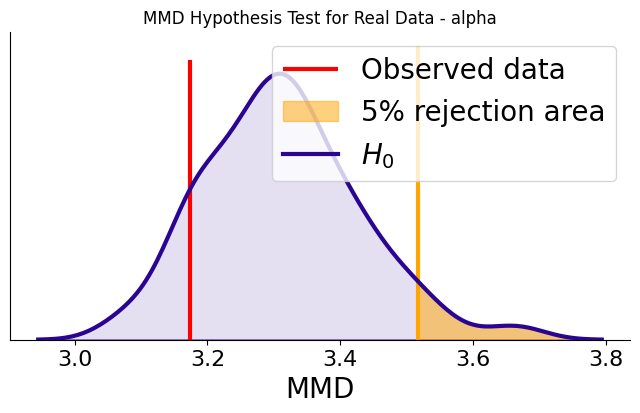

In [46]:
if summary_loss is not None:
    # check the summary statistics
    MMD_sampling_distribution, MMD_observed = trainer.mmd_hypothesis_test(
        observed_data=real_data["summary_conditions"], 
        reference_data=trainer.configurator(valid_data_dict[f'{variant}_pedcov']),  # test against pedcov
        bootstrap=True,  # if True, use the reference data as null samples,
        num_null_samples=1000,
    )
    fig = bf.diagnostics.plot_mmd_hypothesis_test(MMD_sampling_distribution, MMD_observed)
    plt.title(f"MMD Hypothesis Test for Real Data - {variant}")
    plt.show()